In [19]:
import random
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats


<h1>Task 1</h1>

In [20]:

P = np.array([
    [0.9915, 0.005, 0.0025, 0, 0.001],
    [0,      0.986, 0.005,  0.004, 0.005],
    [0,      0,     0.992,  0.003, 0.005],
    [0,      0,     0,      0.991, 0.009],
    [0,      0,     0,      0,     1    ]
])

def simulate(n=1000):
    women = []
    for i in range(n):
        state = 0 
        trajectory = []
        while True:
            trajectory.append(state)
            if state == 4:
                break
            state = np.random.choice(5, p=P[state])
        women.append(trajectory)
    return women
women = simulate(1000)
for i in range(5):
    print(f"Woman {i+1} lived for {len(women[i])} months.")
    print(f"Trajectory: {women[i]}")

def plot_hist(women):
    import matplotlib.pyplot as plt
    lengths = [len(woman) for woman in women]
    plt.hist(lengths, bins=20)
    plt.xlabel("Lifespan (months)")
    plt.ylabel("Frequency")
    plt.title("Distribution of Lifespans")
    plt.show()
    
# This takes a while, so commented out
# plot_hist(women)

Woman 1 lived for 100 months.
Trajectory: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 4]
Woman 2 lived for 186 months.
Trajectory: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 4]
Woman 3 lived for 139 months.
Trajectory: [0, 0, 0, 0, 0

<h1>Task 2</h1>

In [30]:
def analytical_probabilities(P, time=120):
    P_power = np.linalg.matrix_power(P, time)
    return P_power[0]

def empirical_probabilities(women, time=120):
    counts = np.zeros(5)
    for woman in women:
        if len(woman) >= time:
            counts[woman[time-1]] += 1 
        else:
            counts[4] += 1            
    return counts / len(women)

P_120 = analytical_probabilities(P, time=120)
empirical_probs = empirical_probabilities(women, time=120)
print("Analytical state probabilities at 120 months:")
print(np.round(P_120, 4)) # Rounded for easier reading
print("\nEmpirical state probabilities at 120 months:")
print(np.round(empirical_probs, 4))

Analytical state probabilities at 120 months:
[0.359  0.159  0.1661 0.0677 0.2482]

Empirical state probabilities at 120 months:
[0.364 0.176 0.152 0.049 0.259]


In [41]:
#multiply by 1000 to get counts for chi-squared test
observed_counts = empirical_probs * 1000
expected_counts = P_120 * 1000

print("\nObserved counts:", observed_counts)
print("Expected counts:", expected_counts)
stat, p = stats.chisquare(f_obs=observed_counts, f_exp=expected_counts)
print(f"\nChi-squared statistic: {stat:.4f}, p-value: {p:.4f}")


Observed counts: [364. 176. 152.  49. 259.]
Expected counts: [359.02626821 158.95603979 166.08689731  67.74149395 248.18930075]

Chi-squared statistic: 8.7472, p-value: 0.0677


<h1>Task 3</h1>

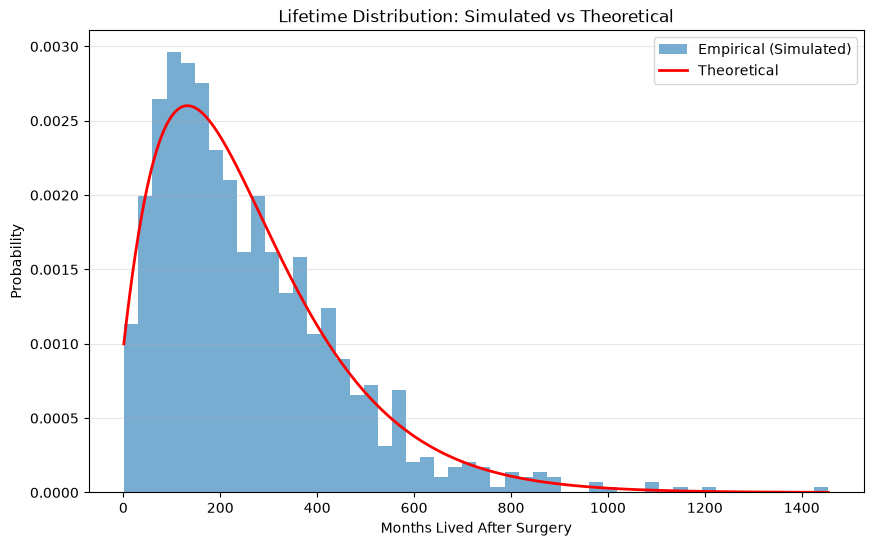

In [62]:
pi = np.array([1, 0, 0, 0])
P_s = P[:-1, :-1]
p_s = P[:-1, -1]

empirical_lifetimes = [len(woman) for woman in women]
max_months = max(empirical_lifetimes)
months = np.arange(1, max_months + 1)
theoretical_pmf = []
for t in months:
    P_s_power = np.linalg.matrix_power(P_s, t - 1) 
    prob = pi @ P_s_power @ p_s
    theoretical_pmf.append(prob)
plt.figure(figsize=(10, 6))
plt.hist(empirical_lifetimes, bins=50, density=True, alpha=0.6, label='Empirical (Simulated)')
plt.plot(months, theoretical_pmf, color='red', label='Theoretical', linewidth=2)
plt.title("Lifetime Distribution: Simulated vs Theoretical")
plt.xlabel("Months Lived After Surgery")
plt.ylabel("Probability")
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.show()

<h1>Task 4</h1>

Blocked 182 out of 1000 simulations (12m).
Blocked 11819 out of 1000 simulations (healthy).

Estimated Expected Lifetime: 181.64 months


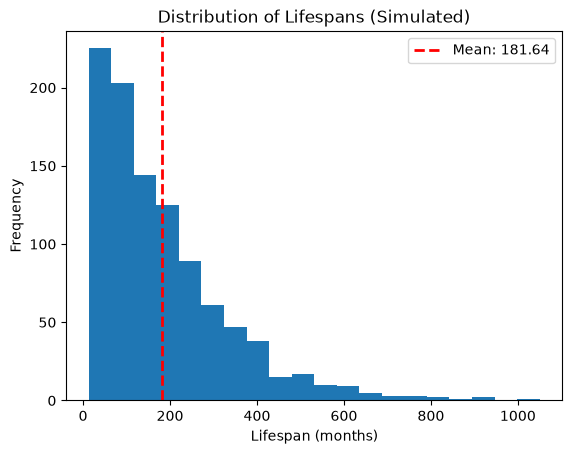

In [ ]:

def simulate_expected_lifespan(n=1000):
    women = []
    blocked_12m = 0
    blocked_healthy = 0
    while len(women) < n:
        state = 0 
        trajectory = []
        while True:
            trajectory.append(state)
            if state == 4:
                break
            state = np.random.choice(5, p=P[state])
        if len(trajectory) <= 12:
            blocked_12m += 1
            continue
        elif trajectory[:12].count(1) + trajectory[:12].count(2) + trajectory[:12].count(3) <= 0:
            blocked_healthy += 1
            continue
        else:
            women.append(trajectory)
    print(f"Blocked {blocked_12m} out of {n} simulations (12m).")
    print(f"Blocked {blocked_healthy} out of {n} simulations (healthy).")
    return women

def plot_expected_lifespan():
    simulated_women = simulate_expected_lifespan(1000)
    expected_lifetimes = [len(woman) for woman in simulated_women]
    mean_lifetime = np.mean(expected_lifetimes)
    print(f"\nEstimated Expected Lifetime: {mean_lifetime:.2f} months")
    plt.hist(expected_lifetimes, bins=20)
    plt.axvline(mean_lifetime, color='red', linestyle='dashed', linewidth=2, label=f'Mean: {mean_lifetime:.2f}')
    plt.xlabel("Lifespan (months)")
    plt.ylabel("Frequency")
    plt.title("Distribution of Lifespans (Simulated)")
    plt.legend()
    plt.show()
# Long runtime, so commented out
# plot_expected_lifespan()


<h1>Task 5</h1>

In [ ]:
def simulate_350_months(n=200):
    survival_rate = []
    for _ in range(100):
        simulated_women = simulate(n)
        count = 0
        for woman in simulated_women:
            if len(woman) < 350:
                count += 1
        survival_rate.append(count / n)
        # if n % 20 == 0:
        #     print(f"Simulation {_+1}/100: {count} out of {n} women lived less than 350 months.")
    print(f"Average survival rate: {np.mean(survival_rate):.2f}")
    return survival_rate

# takes a long time, so commented out
# survival_rates = simulate_350_months(200)
# print(f"Average survival rate across 100 simulations: {np.mean(survival_rates):.2f}")
# print(f"Average death rate across 100 simulations: {1 - np.mean(survival_rates):.2f}")


Simulation 1/100: 143 out of 200 women lived less than 350 months.
Simulation 2/100: 136 out of 200 women lived less than 350 months.
Simulation 3/100: 150 out of 200 women lived less than 350 months.
Simulation 4/100: 155 out of 200 women lived less than 350 months.
Simulation 5/100: 151 out of 200 women lived less than 350 months.
Simulation 6/100: 148 out of 200 women lived less than 350 months.
Simulation 7/100: 151 out of 200 women lived less than 350 months.
Simulation 8/100: 143 out of 200 women lived less than 350 months.
Simulation 9/100: 154 out of 200 women lived less than 350 months.
Simulation 10/100: 141 out of 200 women lived less than 350 months.
Simulation 11/100: 145 out of 200 women lived less than 350 months.
Simulation 12/100: 155 out of 200 women lived less than 350 months.
Simulation 13/100: 146 out of 200 women lived less than 350 months.
Simulation 14/100: 148 out of 200 women lived less than 350 months.
Simulation 15/100: 144 out of 200 women lived less than 3

In [ ]:
def simulate_350_months_control_variate(n=200, iterations=100):
    pi = np.array([1, 0, 0, 0])
    P_s = P[:-1, :-1]
    I = np.eye(4)
    ones = np.ones(4)
    mu_c = pi @ np.linalg.inv(I - P_s) @ ones
    Y_crude = []
    C_means = []
    print(f"Running {iterations} iterations of {n} women...")
    for _ in range(iterations):
        lifetimes = [len(woman) for woman in simulate(n)]
        count_died_early = sum(1 for length in lifetimes if length <= 350)
        Y_crude.append(count_died_early / n)
        C_means.append(np.mean(lifetimes))
    Y = np.array(Y_crude)
    C = np.array(C_means)
    cov_YC = np.cov(Y, C)[0, 1]
    var_C = np.var(C, ddof=1)
    c_star = cov_YC / var_C
    Y_cv = Y - c_star * (C - mu_c)
    var_crude = np.var(Y, ddof=1)
    var_controlled = np.var(Y_cv, ddof=1)
    variance_reduction = (var_crude - var_controlled) / var_crude * 100
    print("\n--- Task 5 Results ---")
    print(f"Theoretical Mean Lifespan (mu_c): {mu_c:.2f} months")
    print(f"Crude Monte Carlo Estimate:       {np.mean(Y):.4f} (Var: {var_crude:.6f})")
    print(f"Control Variate Estimate:         {np.mean(Y_cv):.4f} (Var: {var_controlled:.6f})")
    print(f"Variance Reduction:               {variance_reduction:.2f}%")
    
    return Y_cv

Y_cv = simulate_350_months_control_variate(200, 100)

Running 100 iterations of 200 women...

--- Task 5 Results ---
Theoretical Mean Lifespan (mu_c): 262.37 months
Crude Monte Carlo Estimate:       0.7361 (Var: 0.000915)
Control Variate Estimate:         0.7402 (Var: 0.000425)
Variance Reduction:               53.57%


array([0.73150525, 0.7388013 , 0.7169477 , 0.73535722, 0.72105069,
       0.74073057, 0.7538976 , 0.73007067, 0.80101515, 0.73421   ,
       0.72731727, 0.72728828, 0.74578199, 0.71156421, 0.75282029,
       0.74378838, 0.74068686, 0.74714271, 0.73457976, 0.72522754,
       0.77331237, 0.75594901, 0.7212449 , 0.70550557, 0.76937918,
       0.74259844, 0.74482979, 0.78797717, 0.74928862, 0.74705315,
       0.75763479, 0.74814715, 0.72532545, 0.73934265, 0.73239472,
       0.69891429, 0.73923163, 0.75488399, 0.76969732, 0.75170125,
       0.73356895, 0.73286337, 0.75330106, 0.70111225, 0.75053734,
       0.73858304, 0.77935853, 0.70408966, 0.73698126, 0.71463477,
       0.72618988, 0.76883487, 0.76419888, 0.75782864, 0.72890675,
       0.71895719, 0.73179935, 0.6968899 , 0.71957697, 0.74277479,
       0.74252081, 0.75219871, 0.77238458, 0.76165082, 0.74750852,
       0.74333364, 0.76778395, 0.72600519, 0.72118593, 0.74268406,
       0.7198244 , 0.74062709, 0.70460121, 0.74292395, 0.72161